<h1> Lab 2 Goals </h2>
The objective of this assignment is to implement and evaluate different dimensionality reduction techniques for data visualization and classification. 

The techniques covered include:
<ol>
<li> Laplacian Eigenmaps </li> 
<li> t-SNE </li>
<li> UMAP </li>
</ol>

## Imports

In [1]:
from sklearn.datasets import make_swiss_roll
import numpy as np

import matplotlib.pyplot as plt

### Dataset Preparation

In [2]:
rand_state = 42

In [3]:
def generate_swiss_roll(n_samples=1500, noise=0.1, random_state=rand_state):
    """Generate Swiss Roll dataset with binary labels."""
    # color here is "how far up the data point is in swiss roll"
    X, color = make_swiss_roll(n_samples, noise=noise, random_state=random_state) 
    # Create binary labels based on color for classification task
    y = (color > np.median(color)).astype(int) # splitting the swiss roll exactly on half
    return X, y, color

In [4]:
X, y, color = generate_swiss_roll()

In [5]:
np.sum(y) # showing that the binary labels are dividing the roll in half

750

In [6]:
# Print statements to understand the data structures
print("X shape:", X.shape)
print("First 5 elements of X (3D coordinates):\n", X[:5])

print("\ncolor shape:", color.shape)
print("First 5 elements of color (continuous position):\n", color[:5])

print("\ny shape:", y.shape)
print("First 5 elements of y (binary labels):\n", y[:5])

X shape: (1500, 3)
First 5 elements of X (3D coordinates):
 [[-3.01518102 10.84825125  7.68991191]
 [ 6.1868041  10.11218491 12.26148704]
 [ 6.77416794  0.66808969 -9.46236081]
 [-6.3283099   7.0554887  -8.18321191]
 [ 6.27291634  7.9475574  -0.67339781]]

color shape: (1500,)
First 5 elements of color (continuous position):
 [ 8.24234644 13.67266022 11.61126935 10.35461227  6.18283002]

y shape: (1500,)
First 5 elements of y (binary labels):
 [0 1 1 1 0]


## Exploratory Data Analysis
Visualize the dataset using 2D and 3D scatter plots to observe how the data points are arranged in a spiral-like shape.
- for 2D, since we didn't do any dimensionality reduction yet, we will make scatter plots of pairs of dimensions: dim1 vs dim2, dim1 vs dim3, dim2 vs dim3

Use histograms or box plots to analyze the distribution of values.

Discuss the main challenges of classifying data from the Swiss Roll dataset.

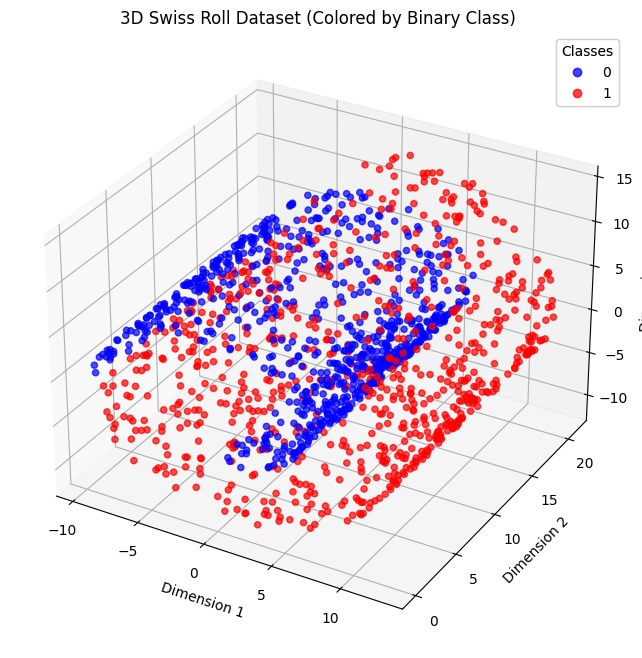

In [7]:
# Create a figure for the plot
fig = plt.figure(figsize=(10, 8))

# Add a 3D subplot specifying the projection
ax = fig.add_subplot(111, projection='3d')

# Extract the three dimensions from your X array
x_coords = X[:, 0]
y_coords = X[:, 1]
z_coords = X[:, 2]

# Plot the 3D scatter plot
# c=y colors the points by their binary class (0 or 1)
# cmap='bwr' uses a blue-white-red color map for clear distinction
scatter = ax.scatter(x_coords, y_coords, z_coords, c=y, cmap='bwr', alpha=0.7, s=20)

# Label the axes to understand the feature space
ax.set_title("3D Swiss Roll Dataset (Colored by Binary Class)")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_zlabel("Dimension 3")

# Add a legend to define the classes
legend = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend)

# Display the plot
plt.show()

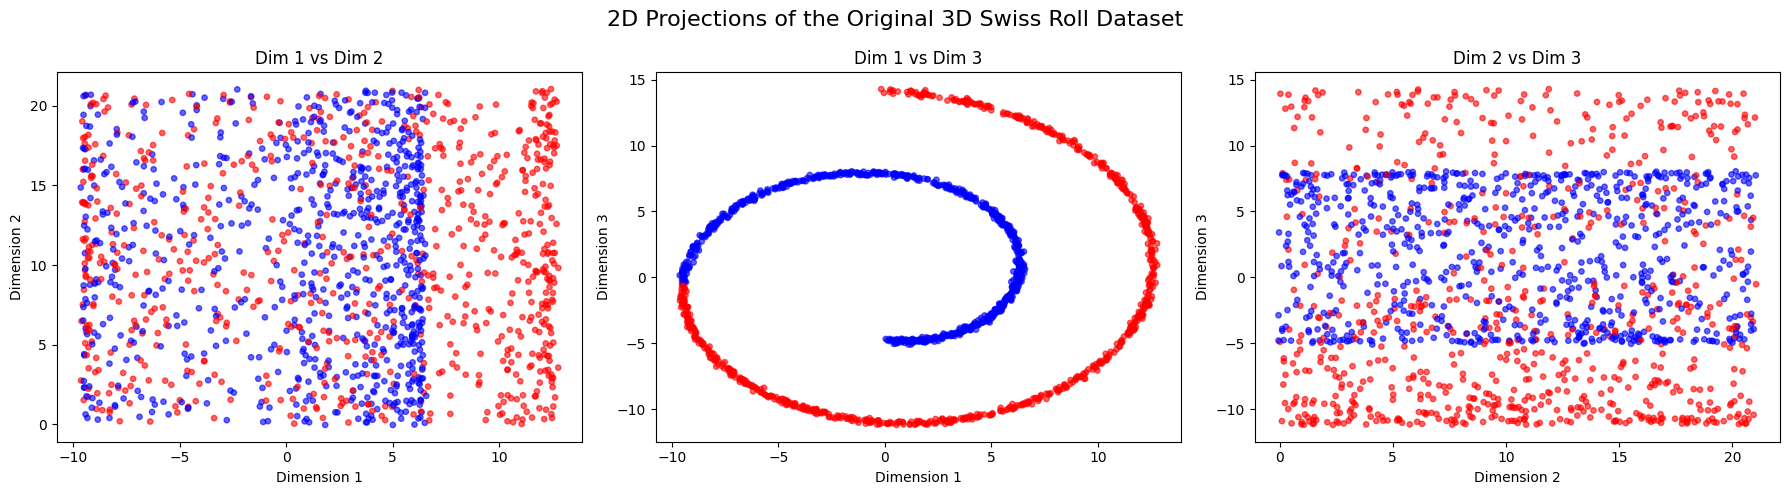

In [8]:
# Create a figure with 3 subplots in a single row
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("2D Projections of the Original 3D Swiss Roll Dataset", fontsize=16)

# Extract dimensions for readability
x1 = X[:, 0]
x2 = X[:, 1]
x3 = X[:, 2]

# Plot 1: Dimension 1 vs Dimension 2
axes[0].scatter(x1, x2, c=y, cmap='bwr', alpha=0.6, s=15)
axes[0].set_title("Dim 1 vs Dim 2")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")

# Plot 2: Dimension 1 vs Dimension 3
axes[1].scatter(x1, x3, c=y, cmap='bwr', alpha=0.6, s=15)
axes[1].set_title("Dim 1 vs Dim 3")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 3")

# Plot 3: Dimension 2 vs Dimension 3
axes[2].scatter(x2, x3, c=y, cmap='bwr', alpha=0.6, s=15)
axes[2].set_title("Dim 2 vs Dim 3")
axes[2].set_xlabel("Dimension 2")
axes[2].set_ylabel("Dimension 3")

plt.tight_layout()
plt.show()

Above is as if we are looking at the 3D Swiss roll directly from the top, the front, and the side

Note the dim1 vs dim3 is the "spiral" or "roll" view. 

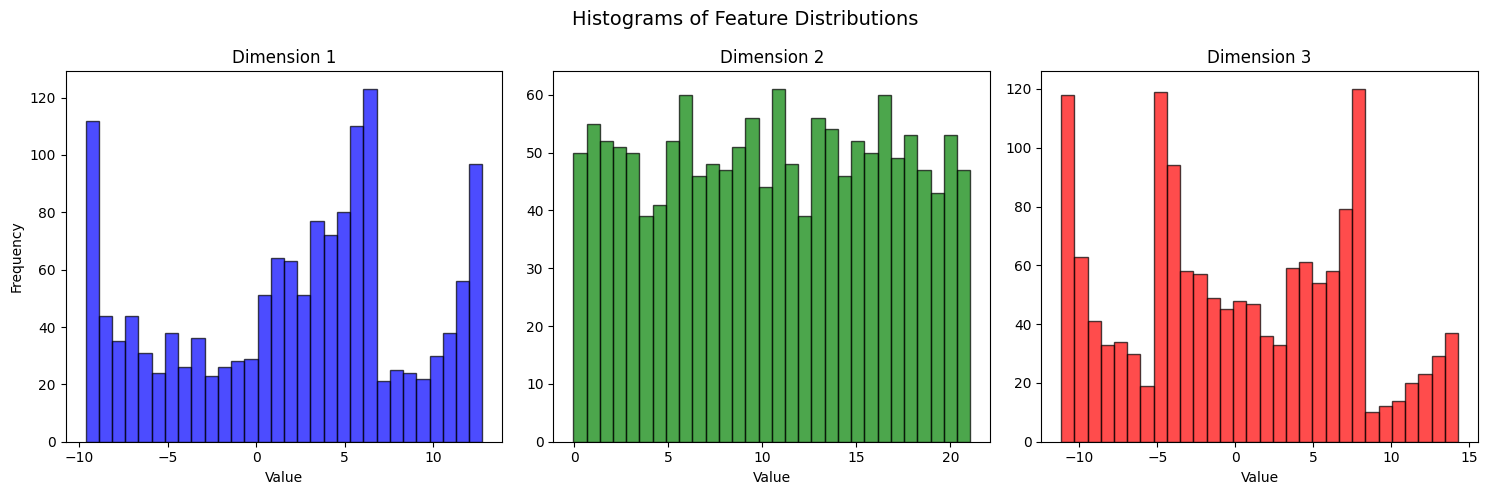

In [9]:
# --- Figure 1: Separate Histograms ---
# Create a figure with 3 subplots in a single row
fig_hist, axes_hist = plt.subplots(1, 3, figsize=(15, 5))
fig_hist.suptitle("Histograms of Feature Distributions", fontsize=14)

# Plot Dimension 1
axes_hist[0].hist(X[:, 0], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes_hist[0].set_title('Dimension 1')
axes_hist[0].set_xlabel('Value')
axes_hist[0].set_ylabel('Frequency')

# Plot Dimension 2
axes_hist[1].hist(X[:, 1], bins=30, color='green', alpha=0.7, edgecolor='black')
axes_hist[1].set_title('Dimension 2')
axes_hist[1].set_xlabel('Value')

# Plot Dimension 3
axes_hist[2].hist(X[:, 2], bins=30, color='red', alpha=0.7, edgecolor='black')
axes_hist[2].set_title('Dimension 3')
axes_hist[2].set_xlabel('Value')

plt.tight_layout()
plt.show()

Note in the histograms, the value is the dimension value, meaning that for example, for dimension 2, it looks like uniform noise, because there's a lot of points with the value for dimension 2 in the same bin. Meaning they are on top of each other in the dimension.

Another example: if the Dimension 1 histogram has a tall bar at the value 10, it means a large number of your 1500 points have an x-coordinate near 10

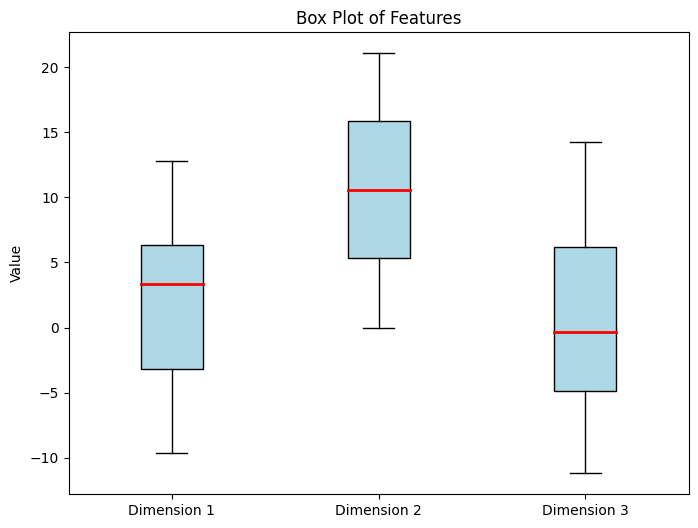

In [10]:
# --- Figure 2: Box Plot ---
# Create a separate figure for the box plot
fig_box = plt.figure(figsize=(8, 6))

plt.boxplot(X, patch_artist=True, 
            labels=['Dimension 1', 'Dimension 2', 'Dimension 3'],
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='red', linewidth=2))
            
plt.title("Box Plot of Features")
plt.ylabel("Value")
plt.show()

### Discussion

Even though the swiss roll was divided by half, there is NO LINEAR SEPARABILITY. We can't simply draw a line or plane to divide the two classes. This is because the underlying data is nonlinear. We can't also use something like KNN because a blue point may have a lot of red points next to it, but if we walk along the roll, it is clearly part of the "blue" features.


We can't also simply drop a feature. When we did that in Dim1 vs Dim2 and Dim2 vs Dim3 all of the points where on top of each other and indistinguishable.

Dim1 vs Dim3 may visualize the geometry a bit better but it still fails to classify the points linearly.

## Laplacian Eigenmaps

Implement Laplacian Eigenmaps from scratch, do not use external libraries.

Use different values of sigma: {0.5, 1, 2}. Use a different number of components {2,5,10,20}.

Plot eigenvalues to show how they contribute to dimensionality reduction. Plot the 2D projection of the dataset. 


![alt text](Images/Laplacian%20Eigenmaps.png)

In [ ]:
def laplacian_eigenmaps(X, n_components=2, sigma=1.0, epsilon=2.0):
    # Step 1: Compute the pairwise distance & weight matrix W
    # W = np.zeros((X.shape[0], X.shape[0]))
    # for i in range(X.shape[0]):
    #     for j in range(X.shape[0]):
    #         dist = np.linalg.norm(X[i] - X[j])
    #         if dist < epsilon:
    #             # Step 2: Construct the adjacency matrix W
    #             W[i, j] = np.exp(-dist**2 / (2 * sigma**2))
    #         else:
    #             W[i, j] = 0

    # Using identity: |A - B|^2 = |A|^2 + |B|^2 - 2A.B
    dist = np.sum(X**2, axis=1, keepdims=True) + np.sum(X**2, axis=1) - 2 * X @ X.T
    W = np.exp(-dist / (2 * sigma**2)) * (dist < epsilon**2)

    # Step 2: Compute the degree matrix D
    # D = np.zeros((X.shape[0], X.shape[0]))
    # for i in range(X.shape[0]):
    #     D[i, i] = np.sum(W[i])
    
    D = np.diag(np.sum(W, axis=1))
    
    # step 3: compute graph Laplacian L
    L = D - W
    normalized_L = np.linalg.inv(D) @ L

    # Step 4: Compute the eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(normalized_L)

    # Step 5: Sort the eigenvalues and select the top n_components
    idx = np.argsort(eigenvalues)
    
    selected_eigenvectors = eigenvectors[:, idx[1:n_components+1]]
    selected_eigenvalues = eigenvalues[idx[1:n_components+1]]
    return selected_eigenvectors, selected_eigenvalues

Text(0.5, 1.0, 'Eigenvalues from Laplacian Eigenmaps')

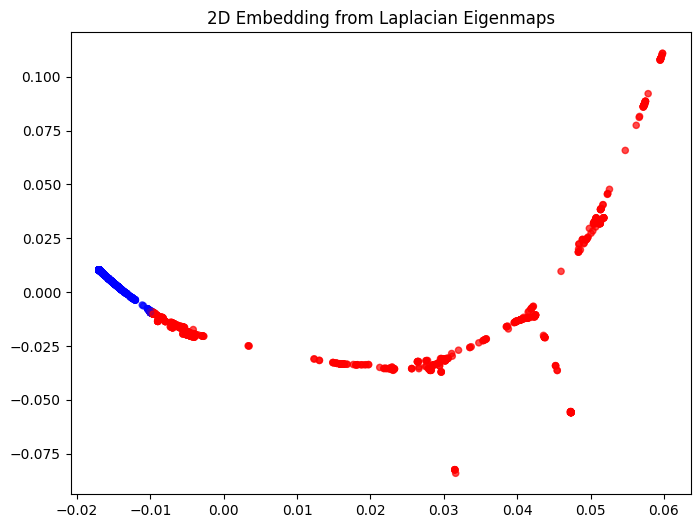

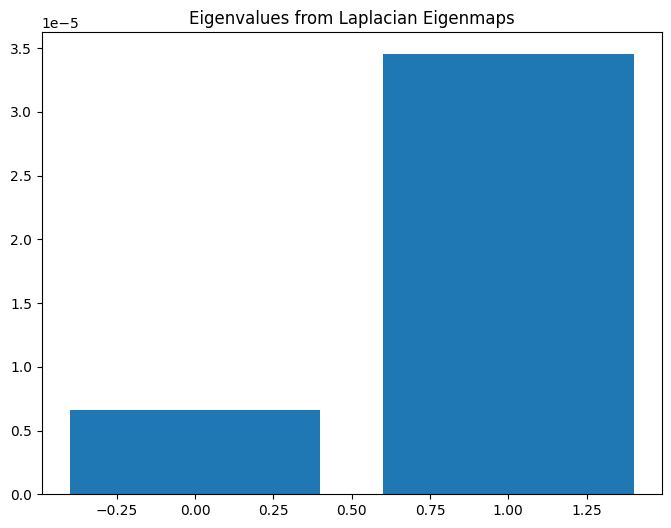

In [22]:
laplacian_x, laplacian_eigenvalues = laplacian_eigenmaps(X, n_components=2, sigma=0.5)

plt.figure(figsize=(8, 6))
plt.scatter(laplacian_x[:, 0], laplacian_x[:, 1], c=y, cmap='bwr', alpha=0.7, s=20)
plt.title("2D Embedding from Laplacian Eigenmaps")

plt.figure(figsize=(8, 6))
plt.bar(range(len(laplacian_eigenvalues)), laplacian_eigenvalues)
plt.title("Eigenvalues from Laplacian Eigenmaps")

Text(0.5, 1.0, 'Eigenvalues from Laplacian Eigenmaps')

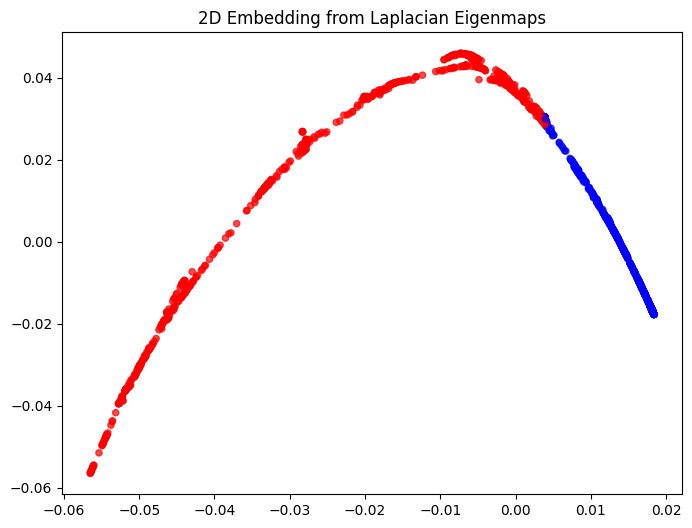

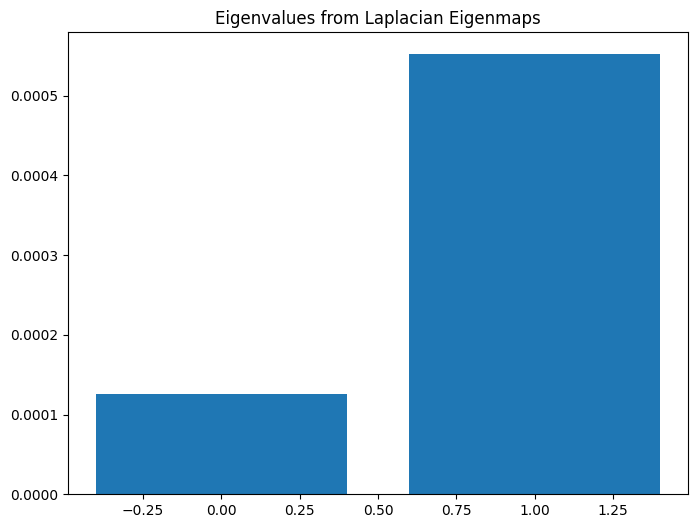

In [19]:
laplacian_x, laplacian_eigenvalues = laplacian_eigenmaps(X, n_components=2, sigma=1.0)

plt.figure(figsize=(8, 6))
plt.scatter(laplacian_x[:, 0], laplacian_x[:, 1], c=y, cmap='bwr', alpha=0.7, s=20)
plt.title("2D Embedding from Laplacian Eigenmaps")

plt.figure(figsize=(8, 6))
plt.bar(range(len(laplacian_eigenvalues)), laplacian_eigenvalues)
plt.title("Eigenvalues from Laplacian Eigenmaps")

Text(0.5, 1.0, 'Eigenvalues from Laplacian Eigenmaps')

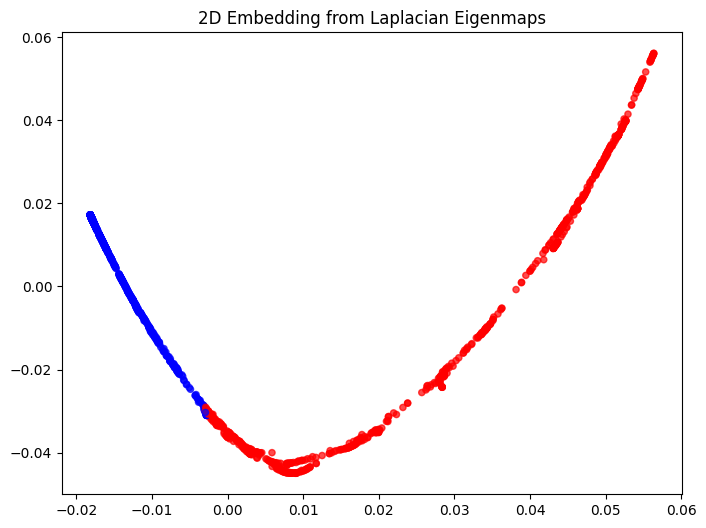

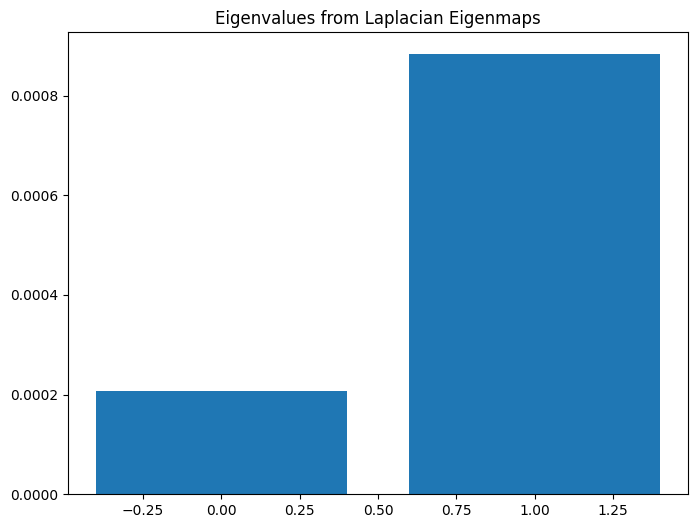

In [15]:
laplacian_x, laplacian_eigenvalues = laplacian_eigenmaps(X, n_components=2, sigma=2.0)

plt.figure(figsize=(8, 6))
plt.scatter(laplacian_x[:, 0], laplacian_x[:, 1], c=y, cmap='bwr', alpha=0.7, s=20)
plt.title("2D Embedding from Laplacian Eigenmaps")

plt.figure(figsize=(8, 6))
plt.bar(range(len(laplacian_eigenvalues)), laplacian_eigenvalues)
plt.title("Eigenvalues from Laplacian Eigenmaps")

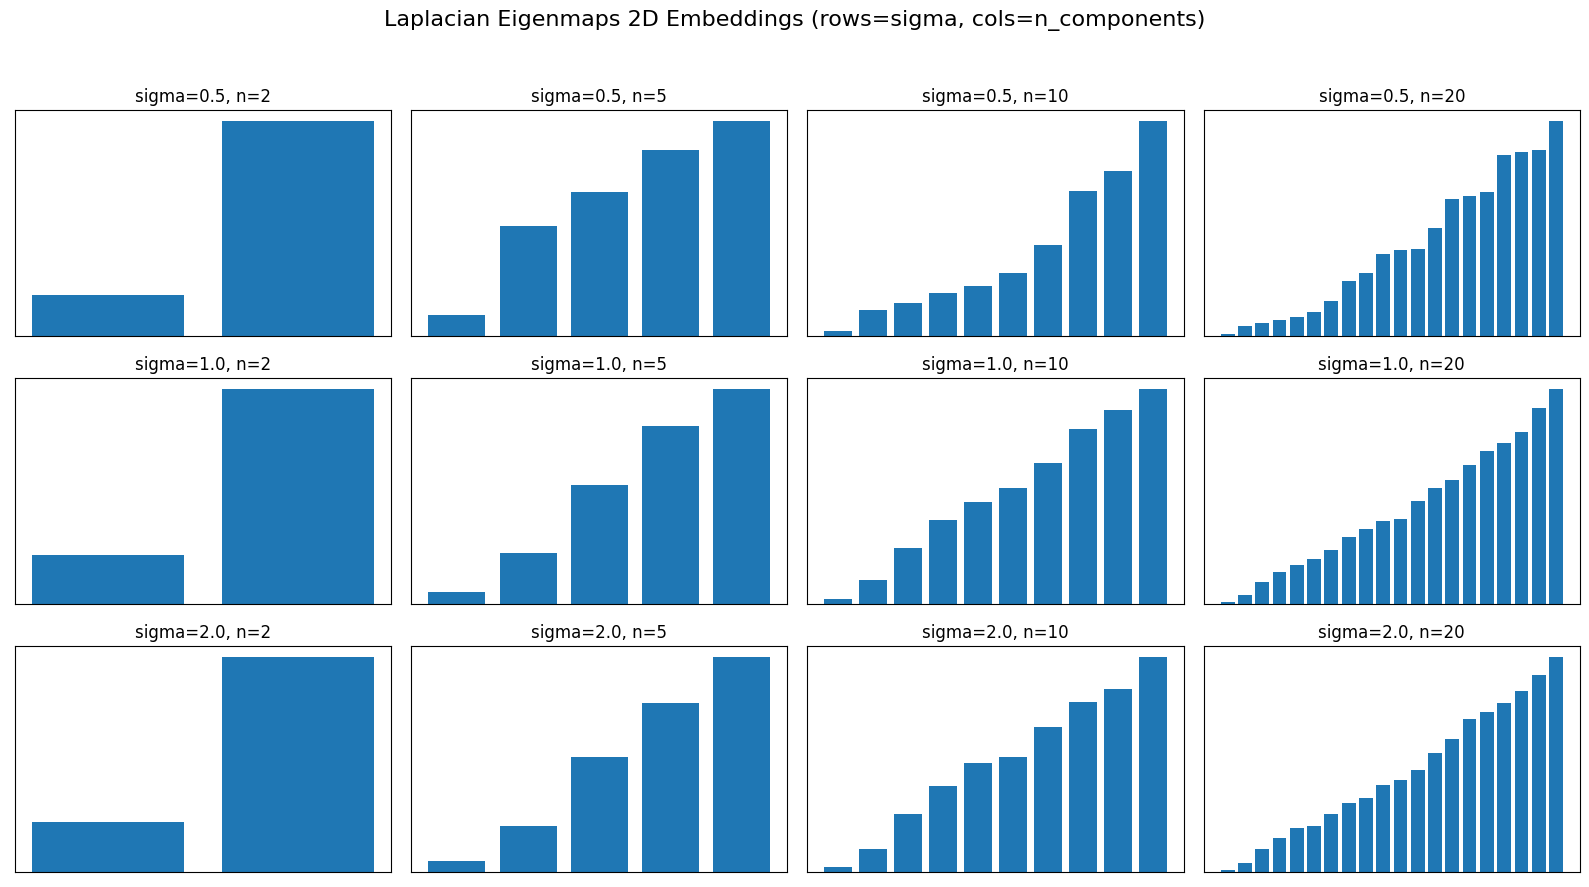

In [23]:
# Plot a grid of 2D embeddings (rows=sigma values, cols=n_components)
sigmas = [0.5, 1.0, 2.0]
n_components_list = [2, 5, 10, 20]

fig, axes = plt.subplots(
    nrows=len(sigmas), ncols=len(n_components_list),
    figsize=(4 * len(n_components_list), 3 * len(sigmas)),
    squeeze=False       
)
fig.suptitle("Laplacian Eigenmaps 2D Embeddings (rows=sigma, cols=n_components)", fontsize=16)

for i, sigma in enumerate(sigmas):
    for j, n_comp in enumerate(n_components_list):
        laplacian_x, laplacian_eigenvalues = laplacian_eigenmaps(X, n_components=n_comp, sigma=sigma)
        ax = axes[i][j]
        ax.bar(range(len(laplacian_eigenvalues)), laplacian_eigenvalues)
        ax.set_title(f"sigma={sigma}, n={n_comp}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()